In [2]:
import sys
sys.path.append('..')

import common.config as cfg
cfg.GPU = True

from common.np import *
from common.layers import MatMul
from common.util import preprocess, create_contexts_target, convert_one_hot, to_gpu
from common.layers import SoftmaxWithLoss, Sigmoid, Embedding, EmbeddingDot, NegativeSamplingLoss
from common.optimizer import Adam
from common.trainer import Trainer
from dataset import ptb

------------------------------------------------------------
                       GPU Mode (cupy)
------------------------------------------------------------



In [ ]:
window_size = 1

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
print(corpus)
print(word_to_id)
print(id_to_word)
contexts, target = create_contexts_target(corpus, window_size=window_size)
print(contexts)
print(target)

In [2]:
# 转换为one-hot表示
print("=====one-hot表示=====")
vocab_size = len(word_to_id)
contexts = convert_one_hot(contexts, vocab_size)
print(contexts)
print(contexts[:, 0])
target = convert_one_hot(target, vocab_size)
print(target)

=====one-hot表示=====
[[[1 0 0 0 0 0 0]
  [0 0 1 0 0 0 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 1 0 0 0]]

 [[0 0 1 0 0 0 0]
  [0 0 0 0 1 0 0]]

 [[0 0 0 1 0 0 0]
  [0 1 0 0 0 0 0]]

 [[0 0 0 0 1 0 0]
  [0 0 0 0 0 1 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 0 0 0 1]]]
[[1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0]]
[[0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0]]


| epoch 1 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 2 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 3 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 4 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 5 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 6 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 7 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 8 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 9 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 10 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 11 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 12 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 13 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 14 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 15 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 16 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 17 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 18 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 19 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 20 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 21 |  iter 1 / 2 | ti

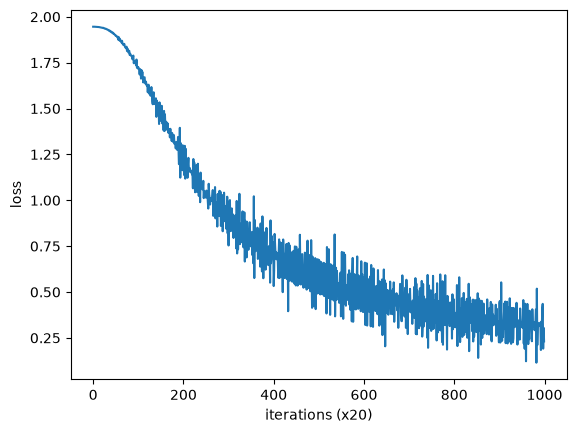

None


In [ ]:
class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size
        w_in = 0.01*np.random.randn(V, H).astype('f')
        w_out = 0.01*np.random.randn(H, V).astype('f')

        # l0和l1共享权重
        self.in_layer0 = MatMul(w_in)
        self.in_layer1 = MatMul(w_in)
        self.out_layer = MatMul(w_out)
        self.loss_layer = SoftmaxWithLoss()

        layers = [self.in_layer0, self.in_layer1, self.out_layer, self.loss_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads
        self.word_vecs = w_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = 0.5*(h0+h1)
        s = self.out_layer.forward(h)
        loss = self.loss_layer.forward(s, target)
        return loss

    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer0.backward(da)
        self.in_layer1.backward(da)
        return None


hidden_size = 5 # 隐藏层维度 也是词向量维度
batch_size = 3
max_epoch = 1000

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)
trainer.fit(contexts, target, max_epoch, batch_size)
print(trainer.plot())

In [5]:
word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])
print(word_vecs.shape)

you [-0.81985766  0.90790546 -0.95352423  1.6536015  -0.8443089 ]
say [ 1.1938192  -1.199359   -0.06166462  0.43368006  1.1890262 ]
goodbye [-1.0649687  0.9311536 -1.0619338 -0.4257436 -1.0667187]
and [ 0.9210052 -0.9676451  1.5099539  1.5116105  0.8963348]
i [-1.1086028   0.94348407 -1.0840038  -0.443333   -1.1276475 ]
hello [-0.81940204  0.8920873  -0.9474761   1.6658937  -0.8456639 ]
. [ 1.079828  -1.0783038 -1.410828  -1.3427536  1.0371393]
(7, 5)


In [3]:
class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size
        # 初始化权重
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(V, H).astype('f')

        # 生成层
        self.in_layers = []
        # 上文 和 下文 所以*2
        for i in range(2 * window_size):
            layer = Embedding(W_in)
            self.in_layers.append(layer)
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        # 将所有的权重和梯度整理到列表中
        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads
        
        # 将单词的分布式表示设置为成员变量
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            # print(type(contexts[:, i]))
            h += layer.forward(contexts[:, i])
        h *= 1 / len(self.in_layers)
        loss = self.ns_loss.forward(h, target)
        return loss

    def backward(self, dout=1):
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)
        for i, layer in enumerate(self.in_layers):
            layer.backward(dout)
        return None

using GPU
[[   0    1    2 ...    8    9   10]
 [   1    2    3 ...    9   10   11]
 [   2    3    4 ...   10   11   12]
 ...
 [ 706 9999  119 ...  258   64   39]
 [9999  119 1143 ...   64   39   26]
 [ 119 1143   69 ...   39   26   24]]
[   5    6    7 ...  552  917 3196]
| epoch 1 |  iter 1 / 9295 | time 0[s] | loss 4.16
| epoch 1 |  iter 2001 / 9295 | time 8[s] | loss 2.86
| epoch 1 |  iter 4001 / 9295 | time 16[s] | loss 2.54
| epoch 1 |  iter 6001 / 9295 | time 25[s] | loss 2.51
| epoch 1 |  iter 8001 / 9295 | time 33[s] | loss 2.49
| epoch 2 |  iter 1 / 9295 | time 38[s] | loss 2.48
| epoch 2 |  iter 2001 / 9295 | time 47[s] | loss 2.44
| epoch 2 |  iter 4001 / 9295 | time 56[s] | loss 2.44
| epoch 2 |  iter 6001 / 9295 | time 64[s] | loss 2.44
| epoch 2 |  iter 8001 / 9295 | time 73[s] | loss 2.43
| epoch 3 |  iter 1 / 9295 | time 78[s] | loss 2.43
| epoch 3 |  iter 2001 / 9295 | time 87[s] | loss 2.37
| epoch 3 |  iter 4001 / 9295 | time 95[s] | loss 2.37
| epoch 3 |  iter 6001

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

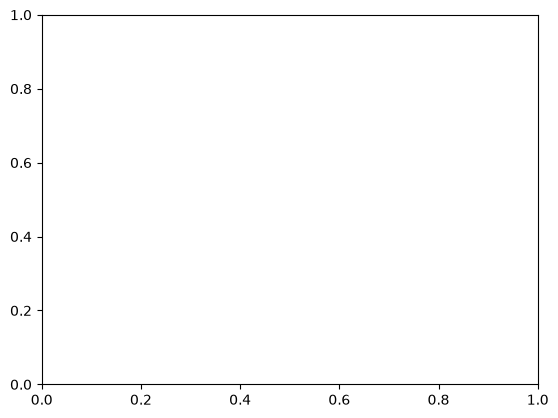

In [9]:
hidden_size = 100 # 隐藏层维度 也是词向量维度
batch_size = 100
max_epoch = 5
window_size = 5

# cfg.GPU = True

corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)
if cfg.GPU:
    print('using GPU')
    contexts, target = to_gpu(contexts), to_gpu(target)

print(contexts)
# print(contexts[:, 0])
print(target)

model = CBOW(vocab_size, hidden_size, 1, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)
trainer.fit(contexts, target, max_epoch, batch_size, eval_interval=2000)
trainer.plot()

word_vecs = model.word_vecs
if cfg.GPU:
    word_vecs = word_vecs.get()
params = {}
params['word_vecs'] = word_vecs
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word
pkl_file = 'cbow_params.pkl'
import pickle

with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)
